In [1]:
import pandas as pd


In [2]:
data=pd.read_csv('genres_v2.csv')

C:\Users\sevil\AppData\Local\Temp\ipykernel_39372\579791698.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('genres_v2.csv')


In [29]:
data

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.059800,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.401000,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.013800,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.023700,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.217000,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42300,0.528,0.693,4,-5.148,1,0.0304,0.031500,0.000345,0.1210,0.3940,...,46bXU7Sgj7104ZoXxzz9tM,spotify:track:46bXU7Sgj7104ZoXxzz9tM,https://api.spotify.com/v1/tracks/46bXU7Sgj710...,https://api.spotify.com/v1/audio-analysis/46bX...,269208,4,hardstyle,NaN,20995.0,Euphoric Hardstyle
42301,0.517,0.768,0,-7.922,0,0.0479,0.022500,0.000018,0.2050,0.3830,...,0he2ViGMUO3ajKTxLOfWVT,spotify:track:0he2ViGMUO3ajKTxLOfWVT,https://api.spotify.com/v1/tracks/0he2ViGMUO3a...,https://api.spotify.com/v1/audio-analysis/0he2...,210112,4,hardstyle,NaN,20996.0,Greatest Hardstyle Playlist
42302,0.361,0.821,8,-3.102,1,0.0505,0.026000,0.000242,0.3850,0.1240,...,72DAt9Lbpy9EUS29OzQLob,spotify:track:72DAt9Lbpy9EUS29OzQLob,https://api.spotify.com/v1/tracks/72DAt9Lbpy9E...,https://api.spotify.com/v1/audio-analysis/72DA...,234823,4,hardstyle,NaN,20997.0,Best of Hardstyle 2020
42303,0.477,0.921,6,-4.777,0,0.0392,0.000551,0.029600,0.0575,0.4880,...,6HXgExFVuE1c3cq9QjFCcU,spotify:track:6HXgExFVuE1c3cq9QjFCcU,https://api.spotify.com/v1/tracks/6HXgExFVuE1c...,https://api.spotify.com/v1/audio-analysis/6HXg...,323200,4,hardstyle,NaN,20998.0,Euphoric Hardstyle


In [30]:
# Importar las librerias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [31]:
#Eliminación de columnas irrelevantes (track_id,track_name, release_date...)
df=data
df = df[[
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]]

In [32]:
df.isnull().sum()


,0
danceability,0
energy,0
loudness,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0
tempo,0
duration_ms,0


In [33]:
#Feature Engineering

#duracion en minutos
df['duration_min'] = df['duration_ms'] / 60000
df.drop(columns=['duration_ms'], inplace=True)

#normalizar loudness
df['loudness_norm'] = df['loudness'].abs() / df['loudness'].abs().max()
df.drop(columns=['loudness'], inplace=True)

#intensidad global
df['intensity'] = (df['energy'] + df['loudness_norm']) / 2

#estado emocional
df['emotion'] = (df['valence'] + df['danceability']) / 2

#presencia vocal
df['vocal_presence'] = (df['speechiness'] + (1 - df['instrumentalness'])) / 2



/tmp/ipython-input-1464262115.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_min'] = df['duration_ms'] / 60000
/tmp/ipython-input-1464262115.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['duration_ms'], inplace=True)
/tmp/ipython-input-1464262115.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-v

In [34]:
conditions = [
        (df['valence'] < 0.5) & (df['energy'] < 0.5),   # Sad
        (df['valence'] >= 0.5) & (df['energy'] < 0.5),  # Calm
        (df['valence'] < 0.5) & (df['energy'] >= 0.5),  # Angry
        (df['valence'] >= 0.5) & (df['energy'] >= 0.5)  # Happy
    ]
choices = [0.0, 1.0, 2.0, 3.0]
df['mood_quadrant'] = np.select(conditions, choices, default=-1.0)

/tmp/ipython-input-3505866208.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mood_quadrant'] = np.select(conditions, choices, default=-1.0)


In [35]:
df

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,loudness_norm,intensity,emotion,vocal_presence,mood_quadrant
0,0.831,0.814,0.4200,0.059800,0.013400,0.0556,0.3890,156.985,2.075650,0.220763,0.517382,0.61000,0.703300,2.0
1,0.719,0.493,0.0794,0.401000,0.000000,0.1180,0.1240,115.080,3.740450,0.216746,0.354873,0.42150,0.539700,0.0
2,0.850,0.893,0.0623,0.013800,0.000004,0.3720,0.0391,218.050,1.647017,0.143388,0.518194,0.44455,0.531148,2.0
3,0.476,0.781,0.1030,0.023700,0.000000,0.1140,0.1750,186.948,2.061017,0.141200,0.461100,0.32550,0.551500,2.0
4,0.798,0.624,0.2930,0.217000,0.000000,0.1660,0.5910,147.988,2.054967,0.229877,0.426938,0.69450,0.646500,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42300,0.528,0.693,0.0304,0.031500,0.000345,0.1210,0.3940,150.013,4.486800,0.154330,0.423665,0.46100,0.515027,2.0
42301,0.517,0.768,0.0479,0.022500,0.000018,0.2050,0.3830,149.928,3.501867,0.237491,0.502746,0.45000,0.523941,2.0
42302,0.361,0.821,0.0505,0.026000,0.000242,0.3850,0.1240,154.935,3.913717,0.092994,0.456997,0.24250,0.525129,2.0
42303,0.477,0.921,0.0392,0.000551,0.029600,0.0575,0.4880,150.042,5.386667,0.143208,0.532104,0.48250,0.504800,2.0


In [37]:
df_cat=df['mood_quadrant']
df=df.drop(columns=['mood_quadrant'])

In [38]:
#normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
import pandas as pd

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df.columns,
    index=df.index
)


In [39]:
df=pd.concat([X_scaled,df_cat],axis=1)

In [41]:
df.head()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,loudness_norm,intensity,emotion,vocal_presence,mood_quadrant
0,1.223608,0.280079,2.246552,-0.212853,-0.727231,-0.902637,0.136790,0.398876,-1.226992,0.304818,0.526660,0.686826,1.270310,2.0
1,0.508480,-1.466185,-0.453057,1.784518,-0.763370,-0.547231,-0.999586,-1.358564,-0.256796,0.259043,-1.661288,-0.471533,0.518809,0.0
2,1.344924,0.709845,-0.588592,-0.482135,-0.763359,0.899456,-1.363655,2.959861,-1.476787,-0.576864,0.537599,-0.329887,0.479525,2.0
3,-1.043093,0.100557,-0.266002,-0.424181,-0.763370,-0.570013,-0.780887,1.655485,-1.235520,-0.601801,-0.231094,-1.061466,0.573013,2.0
4,1.012900,-0.753535,1.239945,0.707390,-0.763370,-0.273841,1.003008,0.021554,-1.239046,0.408666,-0.691030,1.206090,1.009398,3.0


Varianza explicada por cada componente:
[0.29855609 0.17863438]
Varianza total explicada:
0.4771904733800597


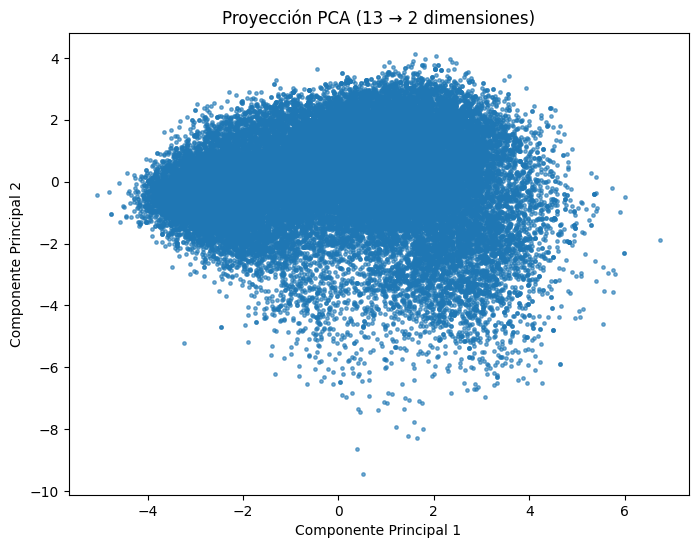

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df)

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada:")
print(pca.explained_variance_ratio_.sum())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=6,
    alpha=0.6
)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA (13 → 2 dimensiones)")
plt.show()



In [50]:
from sklearn.manifold import TSNE
data_sample=df.sample(n=20000,random_state=42)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    init='pca',
    learning_rate='auto',
    random_state=42
)
data_sample_mood=data_sample['mood_quadrant']
data_sample_others=data_sample.drop(columns=['mood_quadrant'])
X_tsne = tsne.fit_transform(data_sample_others)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [52]:
data_tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

# Añadimos la información del Mood para colorear
# Reseteamos índice para que coincida con el array generado por t-SNE
data_tsne_df['Mood'] = data_sample['mood_quadrant'].values


<Figure size 800x600 with 0 Axes>

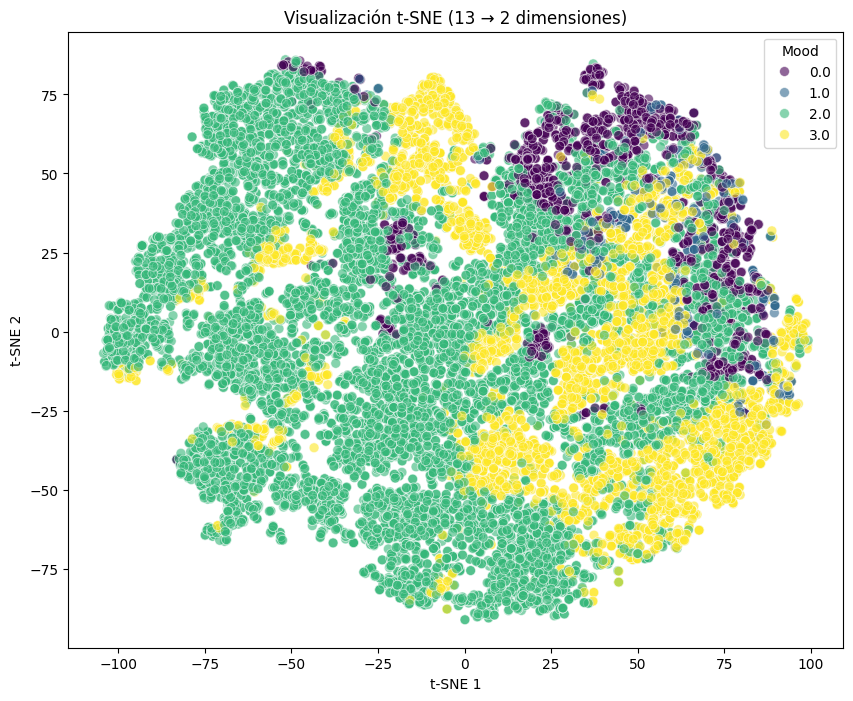

In [54]:
plt.figure(figsize=(8,6))
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=data_tsne_df,
    hue='Mood',
    palette='viridis',
    alpha=0.6,
    s=50
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Visualización t-SNE (13 → 2 dimensiones)")
plt.show()


In [58]:
df_scale=df.drop(columns=['mood_quadrant'])

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(df_scale)
    inertia.append(kmeans.inertia_)


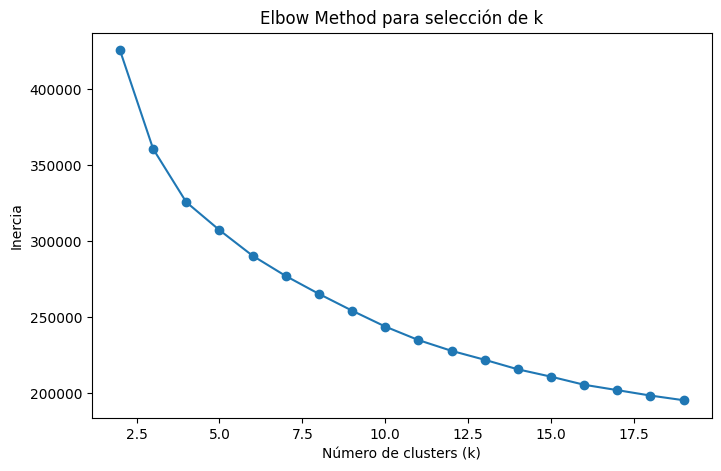

In [61]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Elbow Method para selección de k")
plt.show()


k = 2 → Silhouette = 0.208
k = 3 → Silhouette = 0.196
k = 4 → Silhouette = 0.191
k = 5 → Silhouette = 0.172
k = 6 → Silhouette = 0.173
k = 7 → Silhouette = 0.154
k = 8 → Silhouette = 0.153
k = 9 → Silhouette = 0.159
k = 10 → Silhouette = 0.154
k = 11 → Silhouette = 0.155
k = 12 → Silhouette = 0.152
k = 13 → Silhouette = 0.150
k = 14 → Silhouette = 0.152
k = 15 → Silhouette = 0.154
k = 16 → Silhouette = 0.143
k = 17 → Silhouette = 0.141
k = 18 → Silhouette = 0.143
k = 19 → Silhouette = 0.140


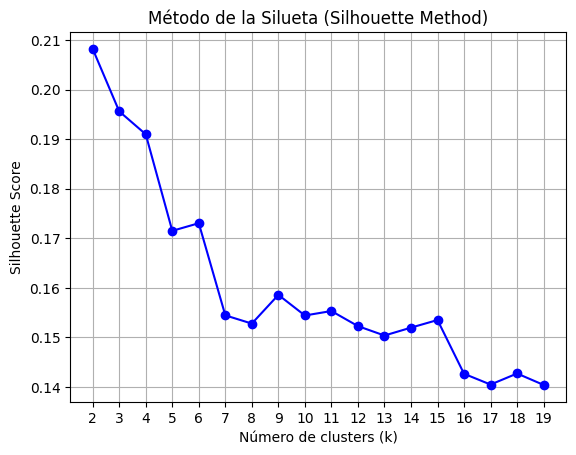

In [63]:
import matplotlib.pyplot as plt

# 1. Crear una lista para almacenar los scores
k_values = range(2, 20)
scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(df_scale)
    score = silhouette_score(df_scale, labels,sample_size=6000,random_state=42)
    scores.append(score) # Guardamos el score
    print(f"k = {k} → Silhouette = {score:.3f}")

# 2. Crear la gráfica
plt.plot(k_values, scores, marker='o', linestyle='-', color='b')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta (Silhouette Method)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Esto no significa que el trabajo esté "mal", sino que los datos probablemente tienen mucho ruido o los grupos están muy traslapados (no son esferas perfectas separadas por el vacío).

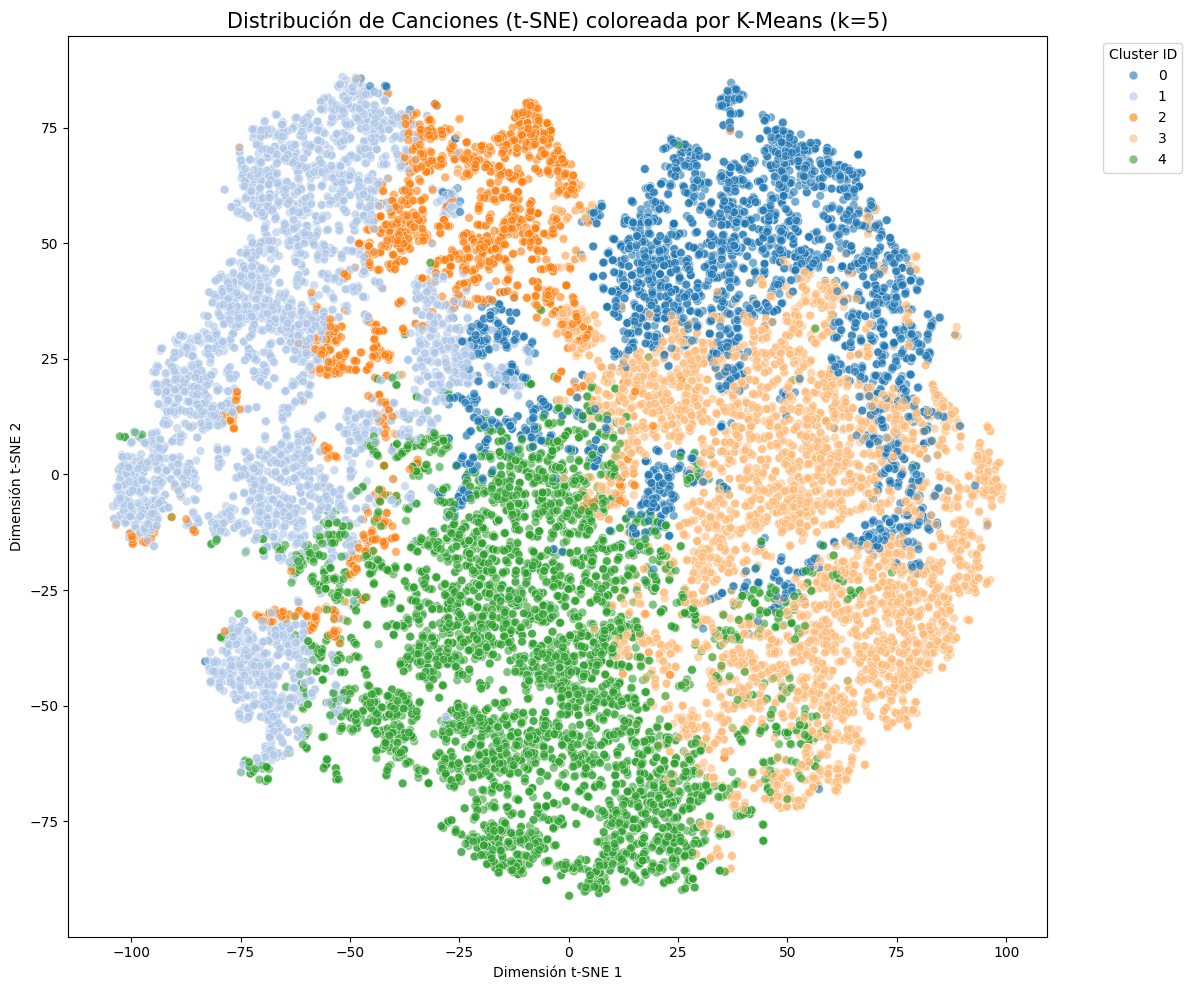

In [68]:
# 1. CONFIGURACIÓN Y MODELADO
optimal_k = 5

# Optimizamos n_init para evitar warnings futuros y fijamos random_state
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Asignamos los clusters al dataset ORIGINAL completo
data['cluster'] = kmeans_final.fit_predict(df_scale)


# 2. ALINEACIÓN DE DATOS
data_tsne_df['cluster'] = data.loc[data_sample.index, 'cluster'].values
data_tsne_df['cluster'] = data_tsne_df['cluster'].astype('category')


# 3. VISUALIZACIÓN
plt.figure(figsize=(12, 10)) # Un poco más grande para K=10

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=data_tsne_df,
    hue='cluster',
    palette='tab20',
    alpha=0.6,
    s=40,
    legend='full'
)

plt.title(f'Distribución de Canciones (t-SNE) coloreada por K-Means (k={optimal_k})', fontsize=15)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster ID')

plt.tight_layout()
plt.show()

#**RESUMEN**
En este proyecto, se ha desarrollado un pipeline completo de aprendizaje no supervisado para segmentar canciones basándose en sus atributos de audio. Los pasos clave realizados fueron:

**1. Preprocesamiento y Feature Engineering:**

Se realizó una limpieza inicial eliminando metadatos irrelevantes como IDs y nombres de pistas para centrarse exclusivamente en las características sonoras.Se transformaron variables crudas en métricas con mayor significado musical: intensity (energía y volumen), emotion (valencia y bailabilidad) y vocal_presence (balance entre habla e instrumentos).Se categorizaron las canciones en un mood_quadrant (Triste, Calma, Enojado, Feliz) basado en el modelo psicológico de valencia y energía.

**2. Preparación y Reducción de Dimensionalidad**

Se aplicó un escalado robusto utilizando StandardScaler para asegurar que todas las variables contribuyeran equitativamente al cálculo de distancias.Se utilizaron técnicas de reducción de dimensiones como PCA y t-SNE para proyectar datos de alta dimensionalidad en un espacio 2D, permitiendo visualizar la estructura y el solapamiento natural de los géneros musicales.

**3. Evaluación y Selección del Modelo**

Se ejecutó el algoritmo K-Means iterando desde $k=2$ hasta $k=20$ para identificar la estructura óptima de grupos.Se empleó el Método del Codo (Inertia) para detectar el punto de rendimientos decrecientes y el Silhouette Score para medir la calidad de la separación entre clusters.Aunque matemáticamente $k=2$ presentaba la mayor cohesión, se seleccionó un valor de $k=5$ (o $k=4$) para capturar una segmentación más rica y accionable que refleje la diversidad de la biblioteca de Spotify.

**4. Resultados Finales**

La visualización final mediante t-SNE muestra cómo el algoritmo K-Means agrupa las canciones de manera coherente, permitiendo identificar patrones que van más allá de los géneros tradicionales, basándose en la "vibra" y la textura sonora de las pistas.

#**Conclusión**
El análisis realizado sugiere que la estructura óptima para este conjunto de datos se encuentra en $k = 5$ clusters.Aunque el Método de la Silueta muestra una puntuación máxima en $k=2$, la inspección del Método del Codo y la necesidad de una segmentación más accionable justifican la elección de 5 grupos. Es importante destacar que los bajos valores de silueta general (máximo de 0.21) indican que las fronteras entre los segmentos son difusas; por lo tanto, los clusters deben interpretarse como tendencias de comportamiento más que como divisiones absolutas.